In [1]:
from dsc80_utils import *

# Lecture 18 – Classifier Evaluation and Model Fairness

## DSC 80, Winter 2026

## Final Exam 📝

- The exam is on **Saturday, March 14th from 8-11AM**.
- You may bring **two 8.5"x11" handwritten note sheets** of your own creation. You must write them yourself on paper (not printed out from a tablet).
- The exam covers every lecture, lab, and project.
- Similar format to the midterm: mix of fill-in-the-blank, multiple choice, and free response.
- Questions on the final covering pre-midterm material will be marked as "M". If you do better on these questions than you did on the midterm exam, we'll replace your score via the [redemption policy](https://dsc80.com/syllabus/#exam-redemption).
- Practice by reviewing lectures and assignments, and working through old exams at [practice.dsc80.com](https://practice.dsc80.com).

### Agenda 📆

- Review: random forests.
- Classifier evaluation.
- Model fairness.

Aside: [MLU Explain](https://mlu-explain.github.io/) is a **great** resource with visual explanations of many of our recent topics (cross-validation, random forests, linear regression, etc.).

## Review: random forests

### Random forests

Random forests are a collection of decision trees that **vote** on a prediction.

<center><img src='imgs/random_forest.png' width=75%></center>

- **Problem:** If you use the same training data, you will always get the same tree.
- **Solution:** Introduce randomness into training procedure to get different trees.
    1. **Bootstrap** the training data so each tree is trained on slightly different data.
    2. At each split, use only a **subset** of the available features so that each tree uses different splitting criteria. 

### Example: Fake news

We have a dataset ([source](https://github.com/KaiDMML/FakeNewsNet)) containing news articles and labels for whether the article was deemed "fake" or "real".

In [2]:
news = pd.read_csv('data/fake_news_training.csv')
news

,baseurl,content,label
0,twitter.com,\njavascript is not available.\n\nwe’ve detect...,real
1,whitehouse.gov,remarks by the president at campaign event -- ...,real
2,web.archive.org,the committee on energy and commerce\nbarton: ...,real
...,...,...,...
658,politico.com,full text: jeff flake on trump speech transcri...,fake
659,pol.moveon.org,moveon.org political action: 10 things to know...,real
660,uspostman.com,"uspostman.com is for sale\nyes, you can transf...",fake


**Goal**: Use an article's content to predict its label.

In [3]:
news['label'].value_counts(normalize=True)

label
real    0.55
fake    0.45
Name: proportion, dtype: float64

**Question**: What is the worst possible accuracy we should expect from a classifier, given the above distribution?

### Aside: `CountVectorizer`

Entries in the `'content'` column are not currently quantitative! We can use the bag of words encoding to create quantitative features out of each `'content'`.

 Instead of performing a bag of words encoding manually as we did before, we can rely on `sklearn`'s `CountVectorizer`. (There is also a `TfidfVectorizer`.)

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

In [5]:
nursery_rhymes = ['Jack be nimble, Jack be quick, Jack jump over the candlestick.', 
                  'Jack and Jill went up the hill to fetch a pail of water.',
                  'Little Jack Horner sat in the corner eating a Christmas pie.']

In [6]:
count_vec = CountVectorizer()
count_vec.fit(nursery_rhymes)

CountVectorizer()

`count_vec` learned a **vocabulary** from the corpus we `fit` it on.

In [7]:
count_vec.vocabulary_

{'jack': 10,
 'be': 1,
 'nimble': 14,
 'quick': 19,
 'jump': 12,
 'over': 16,
 'the': 21,
 'candlestick': 2,
 'and': 0,
 'jill': 11,
 'went': 25,
 'up': 23,
 'hill': 7,
 'to': 22,
 'fetch': 6,
 'pail': 17,
 'of': 15,
 'water': 24,
 'little': 13,
 'horner': 8,
 'sat': 20,
 'in': 9,
 'corner': 4,
 'eating': 5,
 'christmas': 3,
 'pie': 18}

In [8]:
count_vec.transform(nursery_rhymes).toarray()

array([[0, 2, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0]])

Note that  `count_vec.vocabulary_` is a dictionary that maps each word to the associated column in the array above. For example, the first column corresponds to `'and'`.

In [9]:
nursery_rhymes

['Jack be nimble, Jack be quick, Jack jump over the candlestick.',
 'Jack and Jill went up the hill to fetch a pail of water.',
 'Little Jack Horner sat in the corner eating a Christmas pie.']

In [10]:
pd.DataFrame(count_vec.transform(nursery_rhymes).toarray(),
             columns=pd.Series(count_vec.vocabulary_).sort_values().index)

,and,be,candlestick,christmas,...,to,up,water,went
0,0,2,1,0,...,0,0,0,0
1,1,0,0,0,...,1,1,1,1
2,0,0,0,1,...,0,0,0,0


### Creating an initial `Pipeline`

Let's build a `Pipeline` that takes in news article contents and labels and:

- Uses `CountVectorizer` to quantitatively encode article contents.

- Fits a `RandomForestClassifier` to the data to predict the label.

But first, a train-test split (like **always**).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [12]:
X = news['content']
y = news['label']
X_train, X_test, y_train, y_test = train_test_split(X, y)

To start, we'll create a random forest with 100 trees (`n_estimators`) each of which has a maximum depth of 3 (`max_depth`).

In [13]:
pl = Pipeline([
    ('bag-of-words', CountVectorizer()), 
    ('forest', RandomForestClassifier(
        max_depth=3,
        n_estimators=100, # Uses 100 separate decision trees!
        random_state=42   # For reproducibility
    )) 
])

In [14]:
pl.fit(X_train, y_train)

Pipeline(steps=[('bag-of-words', CountVectorizer()),
                ('forest',
                 RandomForestClassifier(max_depth=3, random_state=42))])

In [15]:
# Training accuracy.
pl.score(X_train, y_train)

0.7777777777777778

In [16]:
# Testing accuracy.
pl.score(X_test, y_test)

0.6867469879518072

The accuracy of our random forest is just under 70%, on the test set. How much better does it do compared to a classifier that predicts "real" every time?

In [17]:
y_train.value_counts(normalize=True)

label
real    0.55
fake    0.45
Name: proportion, dtype: float64

In [18]:
# Distribution of predicted ys in the training set:
pd.Series(pl.predict(X_train)).value_counts(normalize=True)

fake    0.65
real    0.35
Name: proportion, dtype: float64

### Choosing tree depth via `GridSearchCV`

We arbitrarily chose `max_depth=3` before, but it seems like that isn't working well. Let's perform a grid search to find the `max_depth` with the best generalization performance.

In [19]:
# Note that we've used the key forest__max_depth, not max_depth
# because max_depth is a hyperparameter of the step we called "forest".
# It is not a hyperparameter of the pipeline, pl.

hyperparameters = {
    'forest__max_depth': np.arange(2, 200, 20)
}

Note that while `pl` has already been `fit`, we can still give it to `GridSearchCV`, which will repeatedly re-`fit` it during cross-validation.

In [20]:
%%time

# Takes a few seconds to run – how many trees are being trained?
from sklearn.model_selection import GridSearchCV
grids = GridSearchCV(
    pl,
    n_jobs=-1, # Use multiple processors to parallelize
    param_grid=hyperparameters,
    return_train_score=True
)
grids.fit(X_train, y_train)

CPU times: user 1.11 s, sys: 251 ms, total: 1.36 s
Wall time: 6.77 s


GridSearchCV(estimator=Pipeline(steps=[('bag-of-words', CountVectorizer()),
                                       ('forest',
                                        RandomForestClassifier(max_depth=3,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'forest__max_depth': array([  2,  22,  42,  62,  82, 102, 122, 142, 162, 182])},
             return_train_score=True)

In [21]:
grids.best_params_

{'forest__max_depth': 42}

Recall, fit `GridSearchCV` objects are estimators on their own as well. This means we can compute the training and testing accuracies of the "best" random forest directly:

In [22]:
# Training accuracy.
grids.score(X_train, y_train)

0.9959595959595959

In [23]:
# Testing accuracy.
grids.score(X_test, y_test)

0.8433734939759037

In [24]:
# Compare to our original model with max_depth = 3.
pl.score(X_test, y_test)

0.6867469879518072

~15% better test set error!

### Training and validation accuracy vs. depth

Below, we plot how training and validation accuracy varied with tree depth. Note that the $y$-axis here is accuracy, and that larger accuracies are better (unlike with RMSE, where smaller was better).

In [25]:
index = grids.param_grid['forest__max_depth']
train = grids.cv_results_['mean_train_score']
valid = grids.cv_results_['mean_test_score']

In [26]:
pd.DataFrame({'train': train, 'valid': valid}, index=index).plot().update_layout(
    xaxis_title='max_depth', yaxis_title='Accuracy'
)

## Classifier Evaluation

### Accuracy isn't everything!

$$
\text{accuracy} = \frac{\text{\# data points classified correctly}}{\text{\# data points}}
$$

* Accuracy is defined as the proportion of predictions that are correct.

* It weighs all **correct** predictions the same, and weighs all **incorrect** predictions the same.

* But some incorrect predictions may be worse than others!
    - Example: **diagnosing a disease** when a person doesn't have it vs. **not diagnosing a disease** when a person does have it.


### The Boy Who Cried Wolf 👦😭🐺 

([source](https://en.wikipedia.org/wiki/The_Boy_Who_Cried_Wolf))

> The tale concerns a shepherd boy who repeatedly tricks villagers into believing a wolf is attacking his flock. When a real wolf appears and the boy cries for help, the villagers dismiss it as another false alarm, allowing the wolf to devour the sheep.

### The wolf classifier

* Predictor: Shepherd boy.
* Positive prediction: "There is a wolf."
* Negative prediction: "There is no wolf."

Some questions to think about:

- What is an example of an incorrect, positive prediction?

- Was there a correct, negative prediction?

- There are four possibilities. What are the consequences of each?
    - (predict yes, predict no) x (actually yes, actually no). 

### Outcomes in binary classification

When performing **binary** classification, there are four possible outcomes. 

|Outcome of Prediction|Definition|True Class|
|---|---|---|
|**True** positive (TP) ✅|The predictor **correctly** predicts the positive class.|P|
|False negative (FN) ❌|The predictor incorrectly predicts the negative class.|P|
|**True** negative (TN) ✅|The predictor **correctly** predicts the negative class.|N|
|False positive (FP) ❌|The predictor incorrectly predicts the positive class.|N|

<center>⬇️</center>

| | Predicted Negative | Predicted Positive |
| --- | --- | --- |
| **Actually Negative** | TN ✅ | FP ❌ |
| **Actually Positive** | FN ❌ | TP ✅ |

<br>

The <b>confusion matrix</b> above summarizes the four possibilities.

Note that in the four acronyms – TP, FN, TN, FP – the **first letter** is whether the prediction is correct, and the **second letter** is what the prediction is.

### Example: Measles outbreak 🔴

- Measles is a highly contagious disease that can cause severe illness. The number of measles cases in the US has surged in recent months.

<center><img src="imgs/measles.jpg" width=75%></center>

- Tests exist to identify active measles infections. Tests can come back
    - positive, indicating that the individual has measles, or
    - negative, indicating that the individual does not have measles.

<div class="alert alert-warning">
    <h3>Question 🤔</h3>
</div>

What is a TP in this scenario? FP? TN? FN?

### Accuracy of measles tests

The results of 100 measles tests are given below.

| | Predicted Negative | Predicted Positive |
| --- | --- | --- |
| **Actually Negative** | TN = 90 ✅ | FP = 1 ❌ |
| **Actually Positive** | FN = 8 ❌ | TP = 1 ✅ |

🤔 **Question:** What is the accuracy of the test?

**🙋 Answer:** $$\text{accuracy} = \frac{TP + TN}{TP + FP + FN + TN} = \frac{1 + 90}{100} = 0.91$$

- **Followup:** At first, the test seems good. But, suppose we build a classifier that predicts that **nobody has measles**. What would its accuracy be?

- **Answer to followup:** Also 0.91! There is severe **class imbalance** in the dataset, meaning that most of the data points are in the same class (no measles). Accuracy doesn't tell the full story.

### Recall

| | Predicted Negative | Predicted Positive |
| --- | --- | --- |
| **Actually Negative** | TN = 90 ✅ | FP = 1 ❌ |
| <span style='color:orange'><b>Actually Positive</b></span> | <span style='color:orange'>FN = 8</span> ❌ | <span style='color:orange'>TP = 1</span> ✅ |

🤔 **Question:** What proportion of individuals who actually have measles did the test **identify**?

**🙋 Answer:** $\frac{1}{1 + 8} = \frac{1}{9} \approx 0.11$

More generally, the **recall** of a binary classifier is the proportion of <span style='color:orange'><b>actually positive instances</b></span> that are correctly classified. We'd like this number to be as close to 1 (100%) as possible.

$$\text{recall} = \frac{TP}{\text{\# actually positive}} = \frac{TP}{TP + FN}$$

To compute recall, look at the <span style='color:orange'><b>bottom (positive) row</b></span> of the above confusion matrix.

### Recall isn't everything, either!

$$\text{recall} = \frac{TP}{TP + FN}$$

🤔 **Question:** Can you design a "measles test" with perfect recall?

**🙋 Answer:** Yes – **just predict that everyone has measles!**

| | Predicted Negative | Predicted Positive |
| --- | --- | --- |
| **Actually Negative** | TN = 0 ✅ | FP = 91 ❌ |
| <span style='color:orange'><b>Actually Positive</b></span> | <span style='color:orange'>FN = 0</span> ❌ | <span style='color:orange'>TP = 9</span> ✅ |

<center><i><small>everyone-has-measles classifier</small></i></center>


$$\text{recall} = \frac{TP}{TP + FN} = \frac{9}{9 + 0} = 1$$

Like accuracy, recall on its own is not a perfect metric. Even though the classifier we just created has perfect recall, it has 91 false positives!

### Precision

| | Predicted Negative | <span style='color:orange'>Predicted Positive</span> |
| --- | --- | --- |
| **Actually Negative** | TN = 0 ✅ | <span style='color:orange'>FP = 91</span> ❌ |
| **Actually Positive** | FN = 0 ❌ | <span style='color:orange'>TP = 9</span> ✅ |

<center><i><small>everyone-has-measles classifier</small></i></center>


The **precision** of a binary classifier is the proportion of <span style='color:orange'><b>predicted positive instances</b></span> that are correctly classified. We'd like this number to be as close to 1 (100%) as possible.

$$\text{precision} = \frac{TP}{\text{\# predicted positive}} = \frac{TP}{TP + FP}$$

To compute precision, look at the <span style='color:orange'><b>right (positive) column</b></span> of the above confusion matrix.

- **Tip:** A good way to remember the difference between precision and recall is that in the denominator for 🅿️recision, both terms have 🅿️ in them (TP and FP).

- Note that the "everyone-has-measles" classifier has perfect recall, but a precision of $\frac{9}{9 + 91} = 0.09$, which is quite low.

- 🚨 **Key idea:** There is a "tradeoff" between precision and recall. Ideally, you want both to be high. For a particular prediction task, one may be important than the other.

### Precision and recall

$$\text{precision} = \frac{TP}{TP + FP} \: \: \: \:  \: \: \: \: \text{recall} = \frac{TP}{TP + FN}$$

<div class="alert alert-warning">
    <h3>Question</h3>
</div>

- When might high **precision** be more important than high recall?

- When might high **recall** be more important than high precision?

### Precision and recall

<center><img src="imgs/Precisionrecall.svg.png" width=30%></center>

<center>(<a href="https://en.wikipedia.org/wiki/Precision_and_recall">source</a>)</center>

### Combining precision and recall

If we care equally about a model's precision $PR$ and recall $RE$, we can combine the two using a single metric called the **F1-score**:

$$\text{F1-score} = \text{harmonic mean}(PR, RE) = 2\frac{PR \cdot RE}{PR + RE}$$

Both F1-score and accuracy are overall measures of a binary classifier's performance. But remember, accuracy is misleading in the presence of class imbalance, and doesn't take into account the kinds of errors the classifier makes.

### Other evaluation metrics for binary classifiers

We just scratched the surface! This [excellent table from Wikipedia](https://en.wikipedia.org/wiki/Template:Diagnostic_testing_diagram) summarizes the many other metrics that exist.

<center><img src='imgs/wiki-table.png' width=75%></center>

If you're interested in exploring further, a good next metric to look at is **true negative rate (i.e. specificity)**, which is the analogue of recall for true negatives.

## Model fairness

### Fairness: why do we care?

- Sometimes, a model performs better for certain groups than others; in such cases we say the model is **unfair**.

- Since ML models are now used in processes that significantly affect human lives, it is important that they are fair!
    * Job applications and college admissions.
    * Criminal sentencing and parole grants.
    * Predictive policing.
    * Credit and loans.

### Model fairness

- We'd like to build a model that is _fair_, meaning that it performs the same for individuals within a group and individuals outside of the group.

- What do we mean by "perform"? What do we mean by "the same"?

<center><img src="imgs/parity.png" width=900></center>

### Parity measures for classifiers

Suppose $C$ is a classifier we've already trained, and $A$ is some binary attribute that denotes whether an individual is a member of a _sensitive_ group – that is, a group we want to avoid discrimination for (e.g. $A = \text{age is less than 25}$).

- $C$ achieves **accuracy parity** if $C$ has the same accuracy for individuals in $A$ and individuals not in $A$.
    - **Example**: $C$ is a binary classifier that determines whether someone receives a loan.
        - If the classifier predicts correctly, then either $C$ approves the loan and it is paid off, or $C$ denies the loan and it would have defaulted.
        - If $C$ achieves accuracy parity, then the proportion of correctly classified loans should be the same for those under 25 and those over 25.

- $C$ achieves **precision (or recall) parity** if $C$ has the same precision (or recall) for individuals in $A$ and individuals not in $A$.
    - Recall parity is often called "true positive rate parity."

- $C$ achieves **demographic parity** if the proportion of predictions that are positive is equal for individuals in $A$ and individuals not in $A$. 

- With the exception of demographic parity, the parity measures above all involve checking whether some evaluation metric (accuracy, precision, or recall) is equal across two groups.

### More on parity measures

- Which parity metric should you care about? It depends on your specific dataset and what types of errors are important!

- Many of these parity measures are **impossible** to satisfy simultaneously!

- The classifier parity metrics mentioned on the previous slide are only a few of the many possible parity metrics. See these [DSC 167 notes](https://afraenkel.github.io/fairness-book/content/05-parity-measures.html) for more details, including more formal explanations.

- These don't apply for regression models; for those, we may care about **RMSE parity** or **$R^2$ parity**. There is also a notion of demographic parity for regression models, but it is outside of the scope of DSC 80.

### Example: Loan approval

As you know from Project 2, LendingClub was a "peer-to-peer lending company"; they [used to publish](https://www.lendingclub.com/info/download-data.action) a dataset describing the loans that they approved.

* `'tag'`: whether loan was repaid in full (1.0) or defaulted (0.0).
* `'loan_amnt'`: amount of the loan in dollars.
* `'emp_length'`: number of years employed.
* `'home_ownership'`: whether borrower owns (1.0) or rents (0.0).
* `'inq_last_6mths'`: number of credit inquiries in last six months.
* `'revol_bal'`: revolving balance on borrows accounts.
* `'age'`: age in years of the borrower (protected attribute).

In [3]:
loans = pd.read_csv(Path('data') / 'loan_vars1.csv', index_col=0)
loans.head()

,loan_amnt,emp_length,home_ownership,inq_last_6mths,revol_bal,age,tag
268309,6400.0,0.0,1.0,1.0,899.0,22.0,0.0
301093,10700.0,10.0,1.0,0.0,29411.0,19.0,0.0
1379211,15000.0,10.0,1.0,2.0,9911.0,48.0,0.0
486795,15000.0,10.0,1.0,2.0,15883.0,35.0,0.0
1481134,22775.0,3.0,1.0,0.0,17008.0,39.0,0.0


The total amount of money loaned was over 5 billion dollars! 

In [28]:
loans['loan_amnt'].sum()

5706507225.0

In [29]:
loans.shape[0]

386772

### Predicting `'tag'`

Let's build a classifier that predicts whether or not a loan was paid in full. If we were a bank, we could use our trained classifier to determine whether to approve someone for a loan!

In [30]:
X = loans.drop('tag', axis=1)
y = loans.tag
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [31]:
clf = RandomForestClassifier(n_estimators=50)
clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50)

Recall, a prediction of 1 means that we predict that the loan will be paid in full.

In [32]:
y_pred = clf.predict(X_test)
y_pred

array([1., 0., 1., ..., 1., 1., 0.])

In [ ]:
clf.score(X_test, y_test)

0.7126782704022008

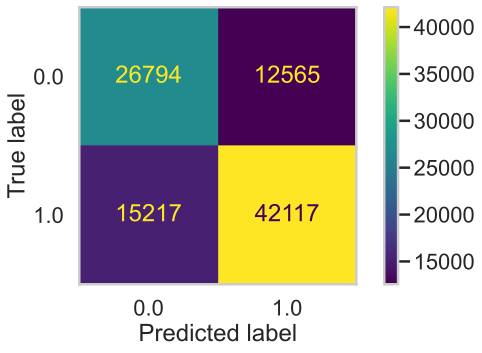

In [34]:
# Import to calculate various metrics, like precision and recall, with sklearn
from sklearn import metrics
metrics.ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test);
plt.grid(False)

### Precision

$$\text{precision} = \frac{TP}{TP+FP}$$

Precision describes the **proportion of loans that were approved that would have been paid back**.

In [35]:
metrics.precision_score(y_test, y_pred)

0.7702168903844043

If we subtract the precision from 1, we get the proportion of loans that were approved that **would not** have been paid back. This is known as the **false discovery rate**.

$$\frac{FP}{TP + FP} = 1 - \text{precision}$$

In [36]:
1 - metrics.precision_score(y_test, y_pred)

0.22978310961559567

### Recall

$$\text{recall} = \frac{TP}{TP + FN}$$

Recall describes the **proportion of loans that would have been paid back that were actually approved**.

In [37]:
metrics.recall_score(y_test, y_pred)

0.7345902954616806

If we subtract the recall from 1, we get the proportion of loans that would have been paid back that **were denied**. This is known as the **false negative rate**.

$$\frac{FN}{TP + FN} = 1 - \text{recall}$$

In [38]:
1 - metrics.recall_score(y_test, y_pred)

0.26540970453831936

From both the perspective of the bank and the lendee, a high false negative rate is bad!
- The bank left money on the table – the lendee would have paid back the loan, but they weren't approved for a loan.
- The lendee deserved the loan, but weren't given one.

### False negative rate by age

In [39]:
results = X_test
results['age_bracket'] = results['age'].apply(lambda x: 5 * (x // 5 + 1))
results['prediction'] = y_pred
results['tag'] = y_test

(
    results
    .groupby('age_bracket')
    [['tag', 'prediction']]
    .apply(lambda x: 1 - metrics.recall_score(x['tag'], x['prediction']))
    .plot(kind='bar', title='False Negative Rate by Age Group')
)

### Computing parity measures

- $C$: Our random forest classifier (1 if we approved the loan, 0 if we denied it).
- $A$: Whether or not they were under 25 (1 if under, 0 if above).

In [40]:
results['is_young'] = (results['age'] < 25).replace({True: 'young', False: 'old'})

First, let's compute the proportion of loans that were approved in each group. If these two numbers are the same, $C$ achieves demographic parity.

In [41]:
results.groupby('is_young')['prediction'].mean()

is_young
old      0.69
young    0.30
Name: prediction, dtype: float64

$C$ evidently does not achieve demographic parity – older people are approved for loans far more often! Note that this doesn't factor in whether they were _correctly_ approved or _incorrectly_ approved.

Now, let's compute the accuracy of $C$ in each group. If these two numbers are the same, $C$ achieves accuracy parity.

In [42]:
compute_accuracy = lambda x: metrics.accuracy_score(x['tag'], x['prediction'])

In [43]:
(
    results
    .groupby('is_young')
    [['tag', 'prediction']]
    .apply(compute_accuracy)
    .rename('accuracy')
)

is_young
old      0.73
young    0.68
Name: accuracy, dtype: float64

Hmm... These numbers look much more similar than before!

### Is this difference in accuracy significant?

Let's run a **permutation test** to see if the difference in accuracy is significant.
- **Null Hypothesis**: The classifier's accuracy is the same for both young people and old people, and any differences are due to chance.
- **Alternative Hypothesis**: The classifier's accuracy is higher for old people.
- Test statistic: Difference in accuracy (young minus old).
- Significance level: 0.01.

In [44]:
obs = (results
       .groupby('is_young')
       [['tag', 'prediction']]
       .apply(compute_accuracy)
       .diff()
       .iloc[-1])
obs

-0.04941426435311924

In [45]:
diff_in_acc = []
for _ in range(500):
    s = (
        results[['is_young', 'prediction', 'tag']]
        .assign(is_young=np.random.permutation(results['is_young']))
        .groupby('is_young')
        [['tag', 'prediction']]
        .apply(compute_accuracy)
        .diff()
        .iloc[-1]
    )
    
    diff_in_acc.append(s)

In [46]:
fig = pd.Series(diff_in_acc).plot(kind='hist', histnorm='probability', nbins=20,
                            title='Difference in Accuracy (Young - Old)')
fig.add_vline(x=obs, line_color='red', line_width=3)
fig.update_layout(xaxis_range=[-0.06, 0.06], showlegend=False)

It seems like the difference in accuracy across the two groups **is significant**, despite being only ~5%. Thus, $C$ likely does not achieve accuracy parity.

### Ethical questions of fairness

- Is it "fair" to deny loans to younger people at a higher rate?

- This is not a *data science* question, it is a political and philosophical question.
    - *But* that doesn't mean that data scientists can ignore it! 

- Federal law prevents age from being used as a determining factor in denying a loan.

Not only should we avoid using `'age'` to determine whether or not to approve a loan, but we also need to be careful to avoid using other features that are strongly correlated with `'age'`, like `'emp_length'`.

In [47]:
loans

,loan_amnt,emp_length,home_ownership,inq_last_6mths,revol_bal,age,tag
268309,6400.0,0.0,1.0,1.0,899.0,22.0,0.0
301093,10700.0,10.0,1.0,0.0,29411.0,19.0,0.0
1379211,15000.0,10.0,1.0,2.0,9911.0,48.0,0.0
...,...,...,...,...,...,...,...
1150493,5000.0,1.0,1.0,0.0,3842.0,52.0,1.0
686485,6000.0,10.0,0.0,0.0,6529.0,36.0,1.0
342901,15000.0,8.0,1.0,1.0,16060.0,39.0,1.0


## Summary

### Summary

- Accuracy alone is not always a meaningful representation of a classifier's quality, particularly when the classes are imbalanced.
    - Precision and recall are classifier evaluation metrics that consider the types of errors being made.
    - There is a "tradeoff" between precision and recall. One may be more important than the other, depending on the task.
- To assess the parity of your model:
    - Choose an evaluation metric, e.g. precision, recall, or accuracy for classifiers, or RMSE or $R^2$ for regressors.
    - Choose a sensitive binary attribute, e.g. "age < 25" or "is data science major", that divides your data into two groups.
    - Conduct a permutation test to verify whether your model's evaluation criteria is similar for individuals in both groups.